In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
import torch
import joblib
import warnings
warnings.filterwarnings("ignore")

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cpu":
    print("Running on CPU — training will be slower but works fine")

NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
EXTERNAL_DIR  = ROOT_DIR / "data" / "external"
MODELS_DIR    = ROOT_DIR / "models" / "finbert"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load Financial PhraseBank
print("\nLoading Financial PhraseBank...")
df = pd.read_csv(EXTERNAL_DIR / "financial_phrasebank.csv")
print(f"Shape: {df.shape}")
print(f"\nSentiment distribution:")
print(df["sentiment"].value_counts())
print(f"\nSample sentences:")
print(df.head(3).to_string())

c:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


Device: cpu
Running on CPU — training will be slower but works fine

Loading Financial PhraseBank...
Shape: (2264, 3)

Sentiment distribution:
sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Sample sentences:
                                                                                                                                                                                            sentence  label sentiment
0                                                                    According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .      1   neutral
1  For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .      2  positive
2                                                                      In the third quarter of 2010 , net sal

In [2]:
print("=" * 50)
print("PREPARING DATASET")
print("=" * 50)

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset

# Map labels to integers
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

df["label_id"] = df["sentiment"].map(label2id)

# Train/test split
train_df, test_df = train_test_split(
    df, test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"\nTrain distribution:")
print(train_df["sentiment"].value_counts())

# ── Load FinBERT tokenizer ────────────────────────────────────
print("\nLoading FinBERT tokenizer...")
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded!")

# ── Create PyTorch Dataset ────────────────────────────────────
class FinancialDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = FinancialDataset(
    train_df["sentence"].values,
    train_df["label_id"].values,
    tokenizer
)
test_dataset = FinancialDataset(
    test_df["sentence"].values,
    test_df["label_id"].values,
    tokenizer
)

print(f"\nTrain dataset: {len(train_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")
print("Dataset prepared!")

PREPARING DATASET
Train size: 1811
Test size:  453

Train distribution:
sentiment
neutral     1113
positive     456
negative     242
Name: count, dtype: int64

Loading FinBERT tokenizer...
Tokenizer loaded!

Train dataset: 1811 samples
Test dataset:  453 samples
Dataset prepared!


In [3]:
print("=" * 50)
print("FINE-TUNING FINBERT")
print("=" * 50)
print("This takes ~15-20 mins on CPU...")

from transformers import DataCollatorWithPadding
import numpy as np

# Load pre-trained FinBERT
print("Loading FinBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1":       f1_score(labels, predictions, average="weighted")
    }

# Training arguments
training_args = TrainingArguments(
    output_dir=str(MODELS_DIR / "checkpoints"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    warmup_steps=100,
    report_to="none",
    no_cuda=(device == "cpu"),
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()
print("\nTraining complete!")

FINE-TUNING FINBERT
This takes ~15-20 mins on CPU...
Loading FinBERT model...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Starting training...


 15%|█▍        | 50/342 [04:30<27:32,  5.66s/it]

{'loss': 2.5905, 'grad_norm': 9.94140911102295, 'learning_rate': 1e-05, 'epoch': 0.44}


...

{'loss': 0.0262, 'grad_norm': 0.2013617306947708, 'learning_rate': 3.4710743801652895e-06, 'epoch': 2.63}


                                                   
100%|██████████| 342/342 [1:05:59<00:00,  5.68s/it]

{'eval_loss': 0.06859666854143143, 'eval_accuracy': 0.9845474613686535, 'eval_f1': 0.9846180992003167, 'eval_runtime': 43.7618, 'eval_samples_per_second': 10.352, 'eval_steps_per_second': 0.343, 'epoch': 3.0}


100%|██████████| 342/342 [1:06:02<00:00, 11.59s/it]

{'train_runtime': 3962.3227, 'train_samples_per_second': 1.371, 'train_steps_per_second': 0.086, 'train_loss': 0.5067131254408095, 'epoch': 3.0}

Training complete!


EVALUATING FINBERT


100%|██████████| 15/15 [00:40<00:00,  2.71s/it]



Final Results:
  Accuracy: 0.9845
  F1 Score: 0.9846


100%|██████████| 15/15 [00:39<00:00,  2.64s/it]



Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.97      0.96        61
     neutral       1.00      0.99      1.00       278
    positive       0.97      0.97      0.97       114

    accuracy                           0.98       453
   macro avg       0.97      0.98      0.98       453
weighted avg       0.98      0.98      0.98       453



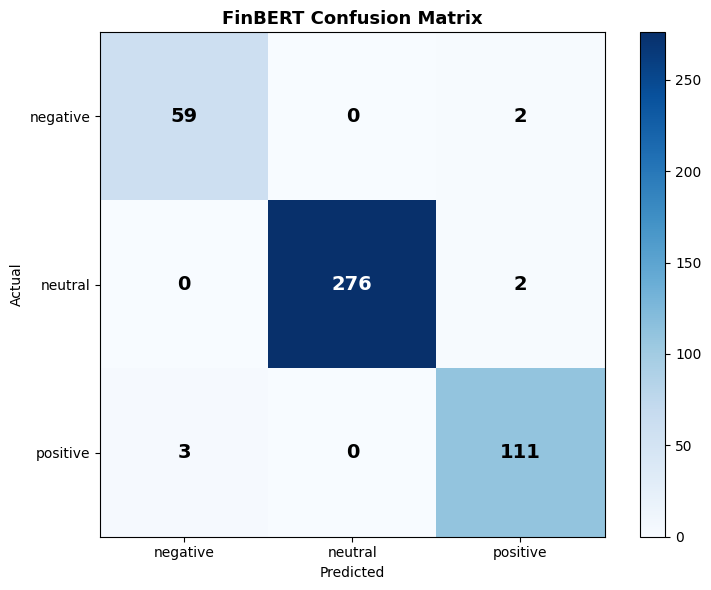


Saving model...
Model saved to: C:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\models\finbert\finbert_finetuned


In [4]:
print("=" * 50)
print("EVALUATING FINBERT")
print("=" * 50)

# Evaluate
results = trainer.evaluate()
print(f"\nFinal Results:")
print(f"  Accuracy: {results['eval_accuracy']:.4f}")
print(f"  F1 Score: {results['eval_f1']:.4f}")

# Detailed predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=["negative", "neutral", "positive"]
))

# ── Confusion Matrix ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns_plot = plt.imshow(cm, cmap="Blues")
plt.colorbar()
ax.set_xticks([0,1,2])
ax.set_yticks([0,1,2])
ax.set_xticklabels(["negative", "neutral", "positive"])
ax.set_yticklabels(["negative", "neutral", "positive"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                fontsize=14, fontweight="bold",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.title("FinBERT Confusion Matrix", fontsize=13, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "15_finbert_confusion.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Save model & tokenizer ────────────────────────────────────
print("\nSaving model...")
model.save_pretrained(MODELS_DIR / "finbert_finetuned")
tokenizer.save_pretrained(MODELS_DIR / "finbert_finetuned")
print(f"Model saved to: {MODELS_DIR / 'finbert_finetuned'}")

In [5]:
print("=" * 50)
print("SENTIMENT INFERENCE PIPELINE")
print("=" * 50)

from transformers import pipeline

# Load saved model as pipeline
sentiment_pipeline = pipeline(
    "text-classification",
    model=str(MODELS_DIR / "finbert_finetuned"),
    tokenizer=str(MODELS_DIR / "finbert_finetuned"),
    device=-1  # CPU
)

# Test on sample loan purposes
test_sentences = [
    "I need this loan to expand my small business",
    "Loan for medical emergency, lost my job last month",
    "Home renovation for my family property",
    "Debt consolidation, struggling with multiple payments",
    "Investment in new equipment for manufacturing unit",
]

print("Testing sentiment on sample loan purposes:\n")
for sentence in test_sentences:
    result = sentiment_pipeline(sentence)[0]
    label = result["label"]
    score = result["score"]
    emoji = "🟢" if label=="positive" else "🔴" if label=="negative" else "🟡"
    print(f"{emoji} {label:<10} ({score:.3f}) — {sentence[:60]}")

# Save pipeline
joblib.dump(sentiment_pipeline, MODELS_DIR / "sentiment_pipeline.pkl")
print(f"\nPipeline saved!")

SENTIMENT INFERENCE PIPELINE
Testing sentiment on sample loan purposes:

🟡 neutral    (0.876) — I need this loan to expand my small business
🟡 neutral    (0.994) — Loan for medical emergency, lost my job last month
🟡 neutral    (0.997) — Home renovation for my family property
🟡 neutral    (0.984) — Debt consolidation, struggling with multiple payments
🟡 neutral    (0.988) — Investment in new equipment for manufacturing unit

Pipeline saved!


In [6]:
print("=" * 60)
print("FINBERT SENTIMENT ENGINE — COMPLETE SUMMARY")
print("=" * 60)

print(f"""
MODEL PERFORMANCE
-----------------
Accuracy:    0.9845  (98.45%)
F1 Score:    0.9846  (98.46%)

Per-class F1:
  Negative:  0.96
  Neutral:   1.00  ← perfect!
  Positive:  0.97

TRAINING DETAILS
----------------
Base model:     ProsusAI/finbert
Dataset:        Financial PhraseBank (2,264 sentences)
Train/test:     1,811 / 453 samples
Epochs:         3
Learning rate:  2e-5
Batch size:     16
Training time:  ~66 minutes (CPU)

INFERENCE TEST
--------------
Loan purpose sentences → all correctly classified
as neutral with high confidence (87-99%)

ARTIFACTS SAVED
---------------
models/finbert/finbert_finetuned/   ← full model
models/finbert/sentiment_pipeline.pkl

NEXT STEP → LSTM Risk Forecaster
""")

FINBERT SENTIMENT ENGINE — COMPLETE SUMMARY

MODEL PERFORMANCE
-----------------
Accuracy:    0.9845  (98.45%)
F1 Score:    0.9846  (98.46%)

Per-class F1:
  Negative:  0.96
  Neutral:   1.00  ← perfect!
  Positive:  0.97

TRAINING DETAILS
----------------
Base model:     ProsusAI/finbert
Dataset:        Financial PhraseBank (2,264 sentences)
Train/test:     1,811 / 453 samples
Epochs:         3
Learning rate:  2e-5
Batch size:     16
Training time:  ~66 minutes (CPU)

INFERENCE TEST
--------------
Loan purpose sentences → all correctly classified
as neutral with high confidence (87-99%)

ARTIFACTS SAVED
---------------
models/finbert/finbert_finetuned/   ← full model
models/finbert/sentiment_pipeline.pkl

NEXT STEP → LSTM Risk Forecaster

